# Shopify Sales Analysis: Investigating a Major Sales Shift

#### Identified and quantified a persistent shift in daily sales using time-series analysis, statistical testing, and visualization. Python, Pandas, SciPy, Matplotlib.

## Business Objective

The objective of this analysis is to identify and understand significant changes in Shopify sales performance over time and translate those findings into actionable business insights.

Specifically, the analysis aims to:

* Identify significant and persistent changes in daily sales.
* Quantify the magnitude and timing of these changes.
* Determine whether the changes are concentrated within specific customer segments.
* Investigate potential business drivers behind major sales shifts.
* Identify what additional data and causal analysis would be needed to determine whether specific business interventions contributed to the observed changes.

Ultimately, the goal is to provide a data-driven framework for understanding changes in sales performance and identifying opportunities to replicate or scale effective business actions.


## Analysis 1 — Exploratory Analysis

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# get all filenames under the data directory 
all_data = [pd.read_csv(filename) for filename in glob.glob("sales_data_analysis_datasets/*.csv")]

# check the list size to understand how many files will be read
# should be equal to 50
print(len(all_data))

#  create the dataset using all files under the data directory
working_df = pd.concat(all_data, axis=0)

df = working_df.copy()

df.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
50


,sale_time,purchaser_gender
0,2013-01-07 02:14:07,female
1,2013-01-07 02:57:53,male
2,2013-01-07 02:59:49,female
3,2013-01-07 03:02:53,male
4,2013-01-07 03:27:36,female


In [49]:
# Number of rows and columns
df.shape

(204329, 2)

In [50]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204329 entries, 0 to 4974
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   sale_time         204329 non-null  object
 1   purchaser_gender  204329 non-null  object
dtypes: object(2)
memory usage: 4.7+ MB


In [51]:
df.describe()

,sale_time,purchaser_gender
count,204329,204329
unique,203411,2
top,2013-06-12 12:26:28,female
freq,3,107740


In [52]:
df['sale_time'].max()

'2013-09-15 23:48:47'

In [53]:
df['sale_time'].min()

'2012-10-01 01:42:22'

In [54]:
df[df.duplicated()]

,sale_time,purchaser_gender
233,2013-01-07 12:22:47,female
351,2013-01-07 15:27:13,female
1322,2013-01-09 15:28:25,female
1594,2013-01-10 08:35:47,female
2052,2013-01-11 05:07:40,female
...,...,...
3958,2013-08-17 14:38:24,female
4234,2013-08-17 21:00:59,female
4571,2013-08-18 12:03:28,female
4633,2013-08-18 13:30:05,male


In [55]:
df = df.drop_duplicates()

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 203821 entries, 0 to 4974
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   sale_time         203821 non-null  object
 1   purchaser_gender  203821 non-null  object
dtypes: object(2)
memory usage: 4.7+ MB


## Analysis 2 — Overall Sales Trend Visualization

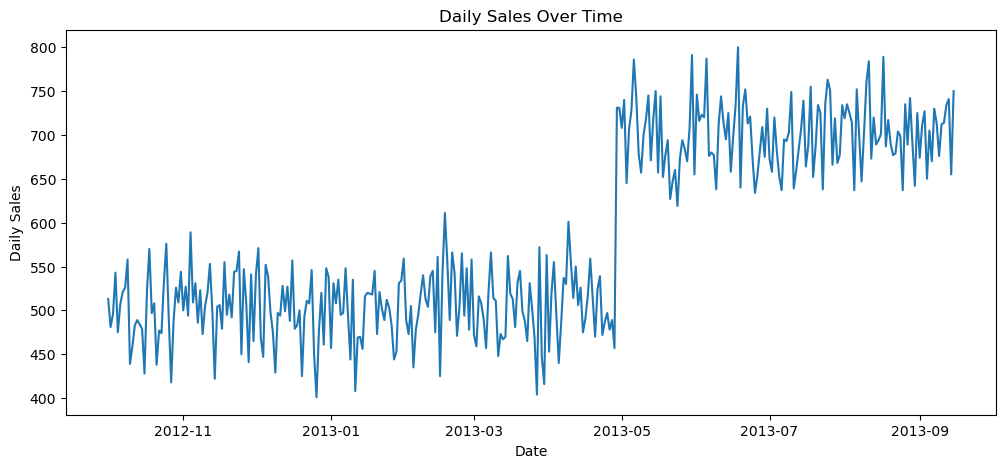

In [57]:
df['sale_time'] = pd.to_datetime(df['sale_time'])

df['sale_date'] = df['sale_time'].dt.date

daily_sales = (
    df
    .groupby('sale_date', as_index=False)
    .agg(
        daily_sales=('purchaser_gender', 'count')
    )
)

plt.figure(figsize=(12, 5))

plt.plot(daily_sales['sale_date'], daily_sales['daily_sales'])

plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.title('Daily Sales Over Time')

plt.show()

### Business Interpretation

The daily sales trend reveals a sharp increase in sales, suggesting that a meaningful shift may have occurred during the period.

The next step is to identify the specific date associated with the largest day-over-day increase so that we can investigate what may have caused the spike and identify potential drivers of the change.

## Analysis 3 — Detecting the Date of the Sudden Change

In [70]:
from scipy import stats

# Find the largest day-over-day change
daily_sales['prev_day_sales'] = (
    daily_sales['daily_sales'].shift(1)
)

daily_sales['sales_change'] = (
    daily_sales['daily_sales']
    - daily_sales['prev_day_sales']
)

change_point = daily_sales[
    daily_sales['sales_change'] == daily_sales['sales_change'].max()
]

print('Largest change:')
print(change_point)

Largest change:
      sale_date  daily_sales  prev_day_sales  sales_change  \
210  2013-04-29          731           457.0         274.0   

     rolling_7_day_sales  time  post_change  time_after_change  \
210           515.857143   210            1                210   

     predicted_sales  
210       699.282067  


### Business Interpretation

The largest positive day-over-day change occurred on April 29, 2013.

Next, we will use a Welch's two-sample t-test to determine whether the change represents a statistically significant shift in the overall level of daily sales. The reason is that a large change in sales does not necessarily mean that the underlying sales level truly changed, sometimes it could be just random variations.

## Analysis 4 — Testing the Statistical Significance of the Change And Quantifying the Business Impact

In [59]:
# Split sales into before and after the change
before = daily_sales[
    daily_sales['sale_date'] < change_date
]['daily_sales']

after = daily_sales[
    daily_sales['sale_date'] >= change_date
]['daily_sales']

# Compare average daily sales
before_mean = before.mean()
after_mean = after.mean()

percent_change = (
    (after_mean - before_mean)
    / before_mean
    * 100
)

# Statistical test
t_stat, p_value = stats.ttest_ind(
    before,
    after,
    equal_var=False
)

# Results
print('Change date:', change_date)
print('Average daily sales before:', before_mean)
print('Average daily sales after:', after_mean)
print('Percentage change:', percent_change)
print('t-statistic:', t_stat)
print('p-value:', p_value)

if p_value < 0.05:
    print('The change is statistically significant.')
else:
    print('The change is not statistically significant.')

Change date: 2013-04-29
Average daily sales before: 503.3142857142857
Average daily sales after: 700.8928571428571
Percentage change: 39.2555063578565
t-statistic: -46.064861938376914
p-value: 1.748078387613175e-138
The change is statistically significant.


### Business Interpretation

The p-value is far below the 0.05 significance threshold. Therefore, we reject the null hypothesis that the two periods have the same mean daily sales. This provides strong statistical evidence that average daily sales differed before and after April 29, 2013.

Average daily sales increased from approximately **503** before the change to **701** after the change. This represents an absolute increase of approximately **198 sales per day**, or a **39% increase**.

Next, we investigate whether the sales increase is persistent or just a temporary spike.

This distinction is important for the business. A temporary spike may have been caused by a short-term event such as a promotion, while a sustained increase could indicate a longer-lasting change in customer behavior or business performance.

We use a 7-day rolling average to smooth out daily fluctuations and evaluate whether the higher sales level continued after April 29.


## Analysis 6 — Was the Change Persistent or Temporary?

In [61]:
daily_sales['rolling_7_day_sales'] = (
    daily_sales['daily_sales']
    .rolling(7)
    .mean()
)

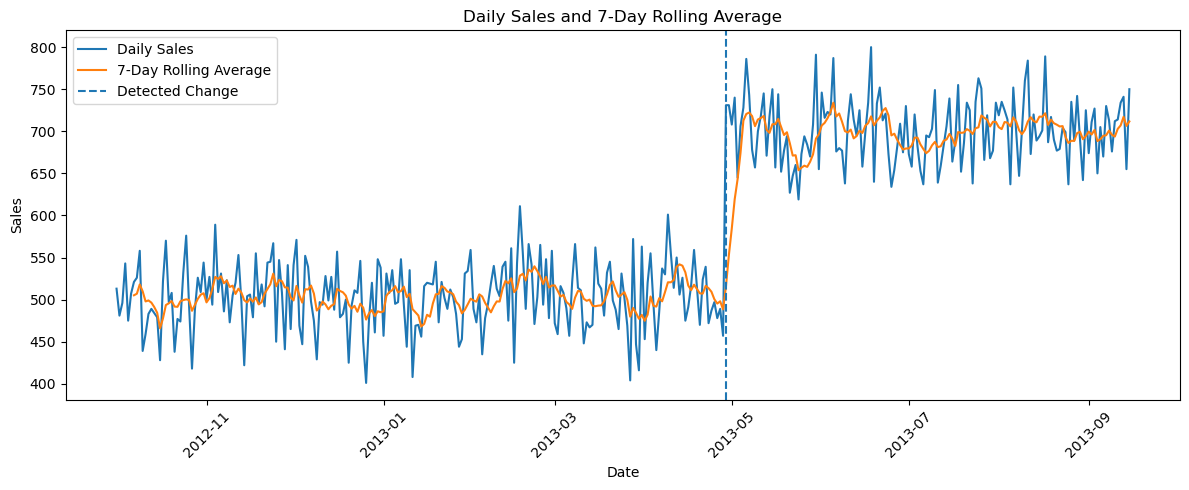

In [62]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales['sale_date'],
    daily_sales['daily_sales'],
    label='Daily Sales'
)

plt.plot(
    daily_sales['sale_date'],
    daily_sales['rolling_7_day_sales'],
    label='7-Day Rolling Average'
)

plt.axvline(
    change_date,
    linestyle='--',
    label='Detected Change'
)

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Daily Sales and 7-Day Rolling Average')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Interpretation

The 7-day rolling average remains substantially higher after the detected date, suggesting that the increase was persistent rather than simply a one-day spike. This indicates that the sales increase may reflect a sustained change in business or product performance, rather than a temporary fluctuation.

Next, we investigate how the sales increase effect by gender. The reason is that understanding which segment contributed to the change can help the business determine whether a particular customer group may have responded differently to whatever happened around April 29.

## Analysis 7A — Segmentation Analysis by Gender

In [63]:
daily_sales_by_gender = (
    df
    .groupby(['sale_date', 'purchaser_gender'], as_index=False)
    .agg(
        sales_count=('sale_time', 'count')
    )
)

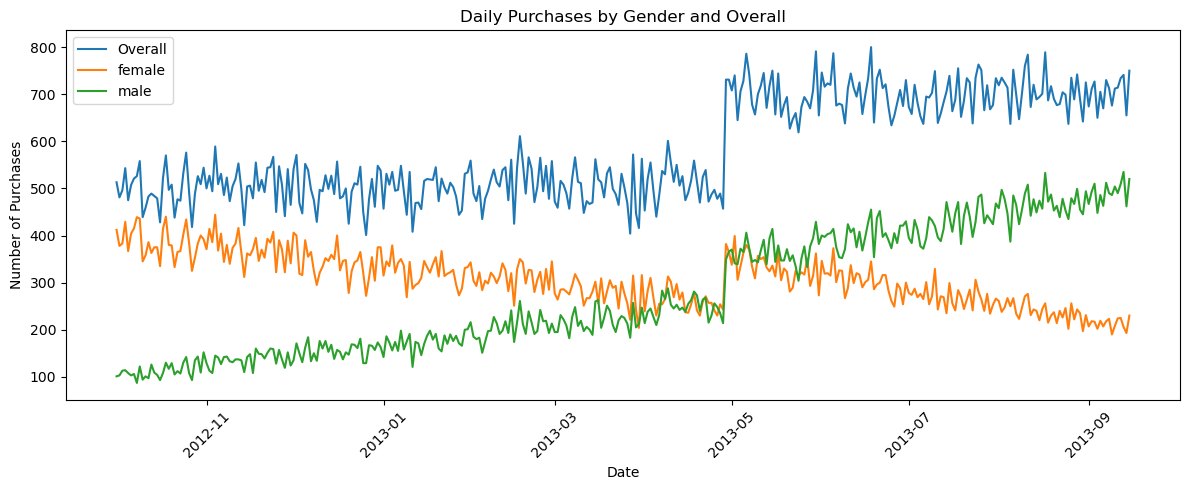

In [64]:
plt.figure(figsize=(12, 5))

# Overall sales
plt.plot(
    daily_sales['sale_date'],
    daily_sales['daily_sales'],
    label='Overall'
)

# Male and Female sales
for gender in daily_sales_by_gender['purchaser_gender'].unique():
    gender_data = daily_sales_by_gender[
        daily_sales_by_gender['purchaser_gender'] == gender
    ]

    plt.plot(
        gender_data['sale_date'],
        gender_data['sales_count'],
        label=gender
    )

plt.xlabel('Date')
plt.ylabel('Number of Purchases')
plt.title('Daily Purchases by Gender and Overall')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

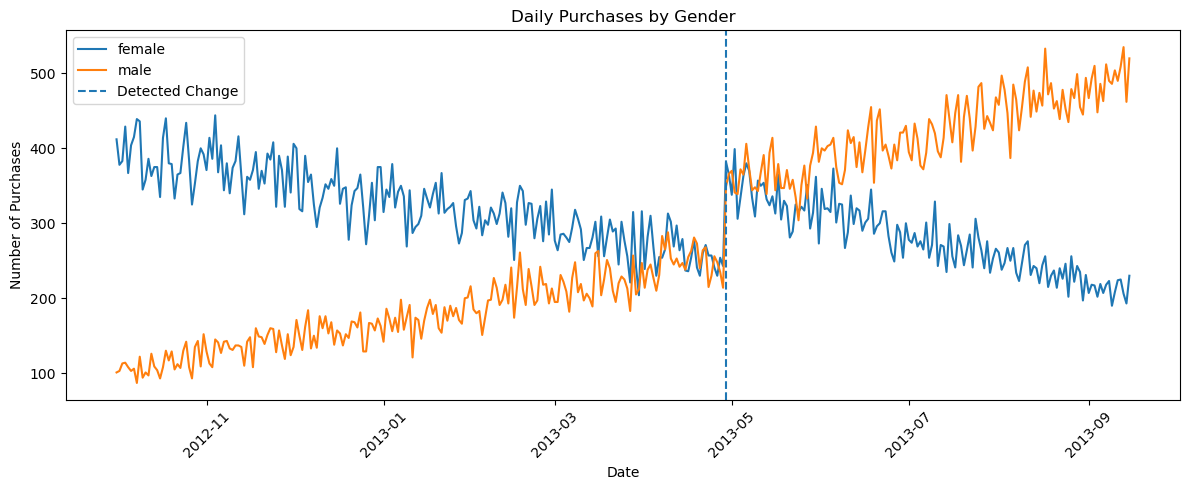

In [65]:
# Plot daily sales by gender
plt.figure(figsize=(12, 5))

for gender in daily_sales_by_gender['purchaser_gender'].unique():

    gender_data = daily_sales_by_gender[
        daily_sales_by_gender['purchaser_gender'] == gender
    ]

    plt.plot(
        gender_data['sale_date'],
        gender_data['sales_count'],
        label=gender
    )

plt.axvline(
    change_date,
    linestyle='--',
    label='Detected Change'
)

plt.xlabel('Date')
plt.ylabel('Number of Purchases')
plt.title('Daily Purchases by Gender')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Business Interpretation

Both groups show a similar increase, the change appears to have affected both segments. This visualization helps us identify patterns visually, next, we quantify the change for each gender.

## Analysis 7B — Quantifying the Gender-Level Change

In [66]:
# Calculate total sales by gender before the change
gender_before = (
    df[df['sale_date'] < change_date]
    .groupby('purchaser_gender')
    .size()
)

# Calculate total sales by gender after the change
gender_after = (
    df[df['sale_date'] >= change_date]
    .groupby('purchaser_gender')
    .size()
)


# Count the number of days in each period
before_days = (
    df[df['sale_date'] < change_date]['sale_date']
    .nunique()
)

after_days = (
    df[df['sale_date'] >= change_date]['sale_date']
    .nunique()
)


# Calculate average daily sales by gender
gender_before_daily = (
    gender_before / before_days
)

gender_after_daily = (
    gender_after / after_days
)


print('Average daily sales by gender before:')
print(gender_before_daily)

print()

print('Average daily sales by gender after:')
print(gender_after_daily)

# Calculate percentage change by gender
gender_percent_change = (
    (gender_after_daily - gender_before_daily)
    / gender_before_daily
    * 100
)

print()

print('Percentage change by gender:')
print(gender_percent_change)


Average daily sales by gender before:
purchaser_gender
female    325.761905
male      177.552381
dtype: float64

Average daily sales by gender after:
purchaser_gender
female    279.107143
male      421.785714
dtype: float64

Percentage change by gender:
purchaser_gender
female    -14.321737
male      137.555651
dtype: float64


### Business Interpretation

The gender-level trends indicate that the increase in overall sales was primarily associated with male purchasers. Male sales were already trending upward before April 29, but the increase became substantially steeper around the detected change point. In contrast, female sales continued to trend downward, although the decline became less pronounced after April 29.

The average daily sales figures support the visual pattern: male sales increased from approximately 178 to 422 per day after the change, while female sales decreased from approximately 326 to 279 per day. This suggests that the overall sales shift was driven primarily by a change in the trajectory of male sales rather than by an increase across both gender segments.

However, this analysis does not establish that the increase in male sales caused the overall increase. Instead, it identifies a customer segment that experienced a particularly large change and provides a direction for further investigation.

## Analysis 9 — Interrupted Time-Series Analysis

The earlier analysis showed that daily sales changed substantially around April 29, 2013. I used a Welch's t-test to confirm that average daily sales before and after this date were statistically different, but this comparison does not account for the underlying time trend.

Because April 29 occurs in the middle of an ongoing sales trajectory, I want to determine whether the level or slope of that trend changed around the detected date.

An interrupted time-series model allows me to estimate the change in sales around April 29 while accounting for the existing trend over time. This helps answer a more specific question:

**After accounting for the underlying sales trend, was there still a meaningful shift in sales around April 29?**


In [67]:
# Create a time index
daily_sales['time'] = range(len(daily_sales))

# Create an indicator for the period after the change
daily_sales['post_change'] = (
    daily_sales['sale_date'] >= change_date
).astype(int)

# Create an interaction term to capture a change in slope
daily_sales['time_after_change'] = (
    daily_sales['time'] * daily_sales['post_change']
)

# Run the interrupted time-series regression
import statsmodels.api as sm

X = daily_sales[
    ['time', 'post_change', 'time_after_change']
]

X = sm.add_constant(X)

y = daily_sales['daily_sales']

its_model = sm.OLS(y, X).fit()

print(its_model.summary())

                            OLS Regression Results                            
Dep. Variable:            daily_sales   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     699.1
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          1.89e-146
Time:                        12:46:52   Log-Likelihood:                -1781.7
No. Observations:                 350   AIC:                             3571.
Df Residuals:                     346   BIC:                             3587.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               501.1740      5.43

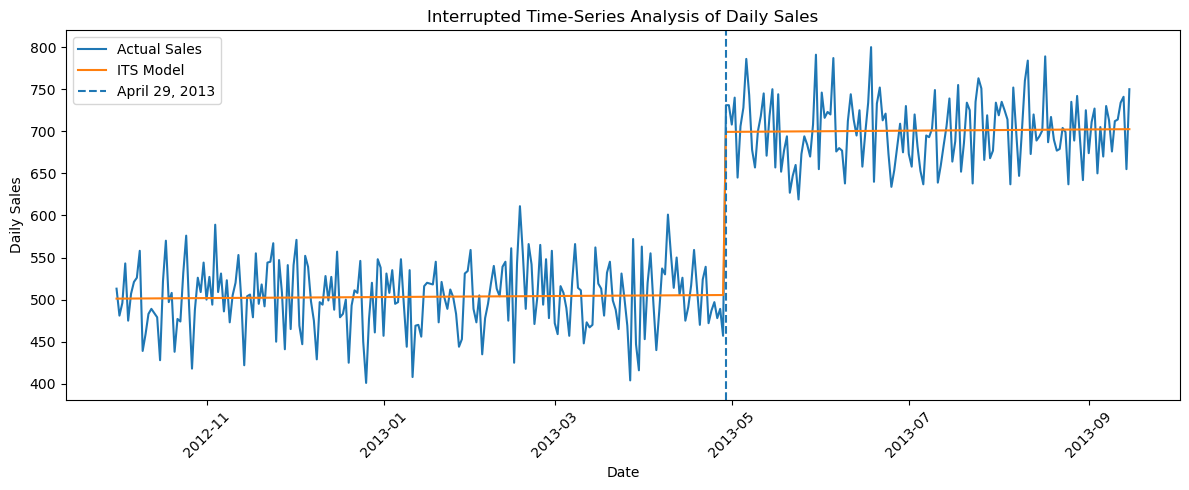

In [68]:
# Fit the Interrupted Time-Series model
daily_sales['time'] = range(len(daily_sales))

daily_sales['post_change'] = (
    daily_sales['sale_date'] >= change_date
).astype(int)

daily_sales['time_after_change'] = (
    daily_sales['time'] * daily_sales['post_change']
)

import statsmodels.api as sm

X = daily_sales[
    ['time', 'post_change', 'time_after_change']
]

X = sm.add_constant(X)

y = daily_sales['daily_sales']

its_model = sm.OLS(y, X).fit()

print(its_model.summary())

### Business Interpretation

The interrupted time-series model indicates that the sales shift around April 29 was primarily an **immediate level increase rather than a change in the underlying sales trend**.

The model estimated an increase of approximately **193 daily sales** at the change point (95% CI: 146–240, p < 0.001). In contrast, there was no statistically significant change in the sales slope after April 29 (p = 0.977).

This suggests that sales moved to a substantially higher level around April 29 and then remained at that higher level, rather than beginning a significantly steeper upward trend.

The model explained approximately **85.8% of the variation in daily sales**, providing a strong fit to the observed data. However, this analysis identifies an association with the April 29 change point and does not establish that a specific business action caused the increase.

The next step would be to connect this time-series finding with business-event data and segment-level analysis to determine what may have contributed to the sustained increase.

## Project Summary

### What did we learn?

The analysis identified a substantial and persistent increase in daily sales around April 29, with the interrupted time-series model estimating an immediate increase of approximately 193 sales per day. The gender analysis also showed that the increase was primarily associated with male purchasers. However, we cannot determine the exact cause from this dataset alone.

### Recommentations For the Next Step

The next step would be to investigate what changed around April 29 by combining the sales data with additional business data, such as marketing campaign exposure, website or product changes, product launches, and acquisition channels.

The male segment would be a particularly useful area for further investigation. Customer-level data, including customer IDs, order history, order value, acquisition source, and product information, could help determine whether the increase was driven by customer acquisition, purchase frequency, order value, or a combination of these factors.

Once potential drivers are identified and the necessary data are available, an appropriate causal inference approach could be used to evaluate whether a specific business intervention contributed to the observed increase. For example, a future intervention could potentially be evaluated through an A/B test, while a historical intervention with an appropriate comparison group could support a difference-in-differences analysis.

This would move the analysis from identifying what changed and what was associated with the change toward understanding what caused the change and which business actions could be replicated or scaled to support future sales growth.


### Limitations

* The dataset contains transaction-level timestamps and purchaser gender but does not include customer identifiers, order value, product information, marketing exposure, acquisition channel, or geographic information.
* Because the underlying cause of the April 29 change is unknown, the analysis cannot attribute the increase to a specific business intervention.
* The pre/post comparison and statistical testing establish a difference in sales levels but do not establish causality.
* The interrupted time-series model identifies a level shift around the change point, but causal interpretation would require stronger assumptions and additional comparison data.
* The dataset covers approximately one year, limiting the ability to assess longer-term seasonal patterns.
